In [ ]:
import os, sys
from pathlib import Path

print("CWD:", os.getcwd())
print("sys.path[0:8]:", sys.path[:8])

# 1) Quita cualquier ruta que meta el repo clonado de scikit-learn
bad_tokens = ["scikit-learn_experiment", r"Auxiliar_kmeans_clusters\scikit-learn_experiment"]

sys.path = [p for p in sys.path if not any(tok in p for tok in bad_tokens)]

# 2) Por si ya se había importado sklearn mal, bórralo del cache
sys.modules.pop("sklearn", None)

print("\nDespués de limpiar:")
print("sys.path[0:8]:", sys.path[:8])

Proyecto root detectado: c:\Users\angel\OneDrive\Documentos\portfolio\Experiments\kmeans_process
sys.path[0:5]: ['c:\\Users\\angel\\OneDrive\\Documentos\\portfolio\\Experiments\\kmeans_process', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\DLLs', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311\\Lib', 'C:\\Users\\angel\\AppData\\Local\\Programs\\Python\\Python311']


In [ ]:
from pathlib import Path
import sys, os

here = Path.cwd()

# Busca hacia arriba un folder que contenga "my_sklearn"
root = None
for p in [here] + list(here.parents):
    if (p / "my_sklearn").exists():
        root = p
        break

print("Proyecto root detectado:", root)

if root is None:
    raise RuntimeError("No encuentro la carpeta my_sklearn hacia arriba desde el CWD.")

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("sys.path[0:5]:", sys.path[:5])

c:\Users\angel\OneDrive\Documentos\portfolio\Experiments\kmeans_process\my_sklearn\cluster\_kmeans.py


In [3]:
import sklearn
print("sklearn importado desde:", sklearn.__file__)

sklearn importado desde: c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\__init__.py


In [5]:
import my_sklearn.cluster._kmeans as my_kmeans
print("mi _kmeans está en:", my_kmeans.__file__)
import sklearn
print("sklearn está en:", sklearn.__file__)

mi _kmeans está en: c:\Users\angel\OneDrive\Documentos\portfolio\Experiments\kmeans_process\my_sklearn\cluster\_kmeans.py
sklearn está en: c:\Users\angel\OneDrive\Documentos\portfolio\.venv\Lib\site-packages\sklearn\__init__.py


# Objetivo del Cuaderno

**Objetivo:**  
Este cuaderno tiene como objetivo visualizar y comprender el proceso iterativo de cómo se eligen los **centroides** en el modelo **K-Means** durante cada iteración. A través de una serie de pasos, exploraremos cómo el algoritmo ajusta progresivamente la posición de los centroides para agrupar los datos de manera más precisa.

## Proceso del Algoritmo K-Means

1. **Inicialización de Centroides:**
   El algoritmo comienza seleccionando aleatoriamente los centroides iniciales. Estos centroides son los puntos representativos de cada clúster (grupo) en el espacio de características de los datos.

2. **Asignación de Puntos a los Centroides:**
   En cada iteración, el algoritmo asigna cada punto de datos al centroide más cercano. La asignación se realiza utilizando la **distancia euclidiana** (o cualquier otra métrica de distancia) entre los puntos de datos y los centroides.

3. **Recalculo de los Centroides:**
   Después de asignar todos los puntos a sus respectivos centroides, el algoritmo recalcula las posiciones de los centroides como el **promedio** de los puntos asignados a cada uno. Este nuevo centroide representa el "centro" del clúster para la siguiente iteración.

4. **Iteración:**
   Los pasos anteriores (asignación de puntos y recalculo de centroides) se repiten de manera iterativa. El proceso continúa hasta que los centroides ya no cambian significativamente, lo que indica que el algoritmo ha convergido y los clústeres son estables.

## Visualización de las Iteraciones

A lo largo de este cuaderno, se mostrará cómo los **centroides** se ajustan progresivamente y cómo los puntos de datos se agrupan en torno a ellos. En cada iteración, los centroides se desplazarán hacia nuevas posiciones, mientras que los puntos de datos se asignarán gradualmente a los clústeres correspondientes. El objetivo es observar cómo, a medida que avanzan las iteraciones, los centroides convergen en posiciones más estables y representativas de los grupos en los datos.

Este cuaderno permite una comprensión visual y práctica del funcionamiento del **algoritmo K-Means** en términos de su convergencia y la asignación de puntos a clústeres.

---


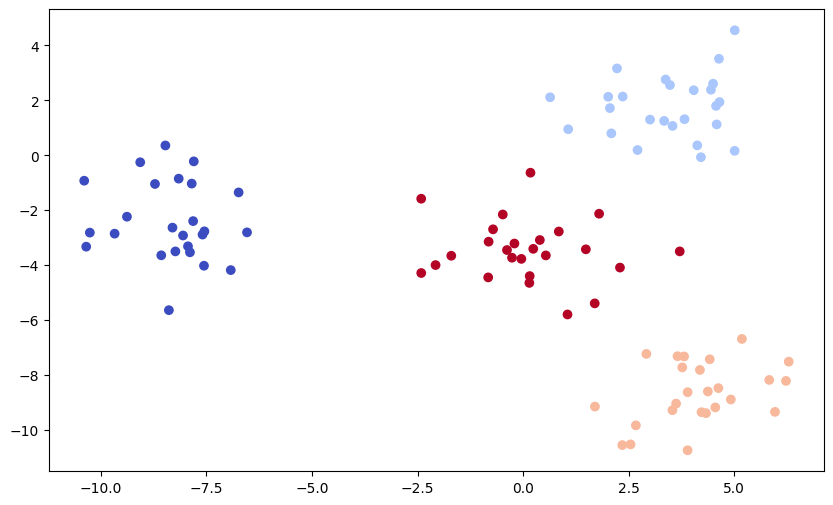

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
x, y = make_blobs(n_samples=100, centers=4,
                  random_state=500, cluster_std=1.25)

model = KMeans(n_clusters=4, random_state=0, n_init='auto')
model.fit(x)

y_ = model.predict(x)
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], x[:, 1], c=y_,  cmap='coolwarm');

inicia [[-30413.21514678  -8198.81558552]
 [ -7305.42666594   2328.82785835]
 [  7558.59877571   6491.29785248]
 [ 12509.86029607 -11145.60089665]
 [  -144.58293097 -11713.78035387]
 [ -5750.92182893  25257.91582602]
 [ -9363.51070192  12170.79401463]
 [-18078.29128348  -5863.76803152]]
Centros  [[-27756.82128013  -6782.77419787]
 [ -5609.32258228   1238.24854251]
 [  8041.87510604   6451.40277295]
 [ 12990.98798901  -9261.04614479]
 [  -901.0870696  -10903.80693365]
 [  -728.20909919  22191.87097734]
 [ -9045.95073304  11829.68096003]
 [-15585.5964777   -6243.18513698]]


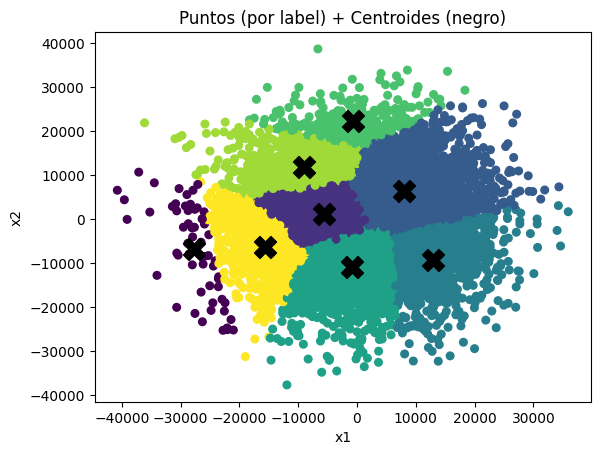

Centros  [[-25615.02488418  -4018.99511539]
 [ -4340.99096056    991.55237801]
 [  8536.46731136   6300.03383493]
 [ 12874.41826363  -8451.13603214]
 [  -651.37866523 -11327.66778504]
 [  1960.39268041  19858.98052084]
 [ -9509.66304745  11190.57339597]
 [-14218.57409257  -6428.80824868]]


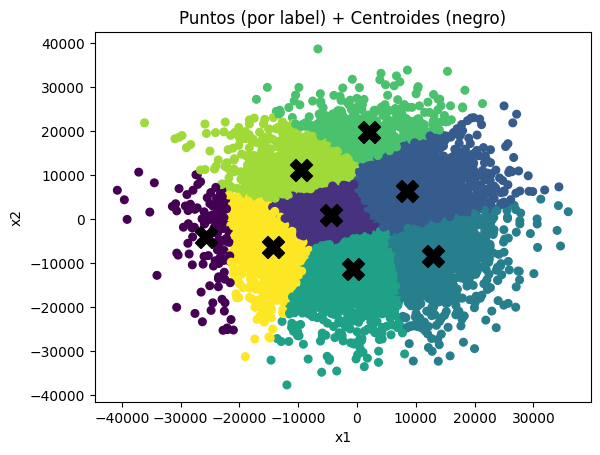

Centros  [[-23727.81532784  -1148.16410709]
 [ -3251.18742381    884.26184779]
 [  8972.2076473    5920.73608149]
 [ 12790.48612004  -8056.61818273]
 [  -409.77921234 -12051.09406618]
 [  3398.55391221  18428.07941385]
 [ -9926.51922252  10884.20160986]
 [-13064.66829684  -6928.79175459]]


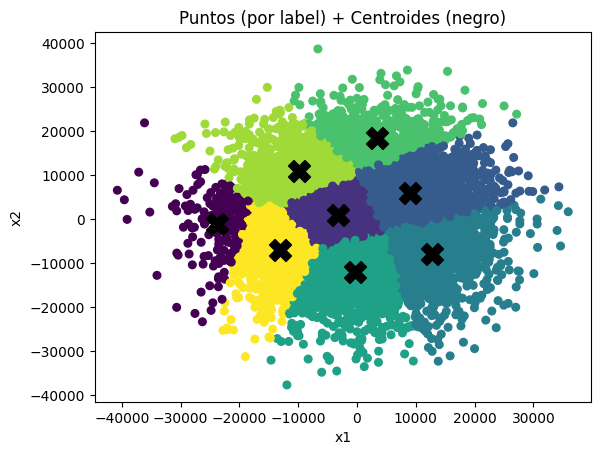

Centros  [[-21791.00072739    907.8477708 ]
 [ -2485.38031964    839.02227997]
 [  9581.01729487   5558.67182167]
 [ 12694.62912748  -7919.84559968]
 [  -151.85840034 -12724.20430324]
 [  3900.63787723  17313.40880711]
 [ -9822.84704835  10820.61027064]
 [-12233.5066907   -7384.57277834]]


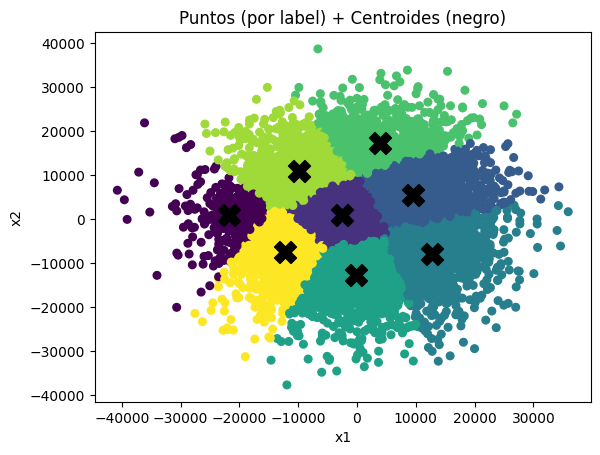

Centros  [[-20293.1766675    1714.69403354]
 [ -1930.14961045    760.60301885]
 [ 10254.37598569   5397.92175269]
 [ 12657.08446453  -7861.76676132]
 [   145.064633   -13312.2154838 ]
 [  4018.27082728  16795.38119133]
 [ -9510.16520867  10844.36084977]
 [-11740.61238254  -7703.90058478]]


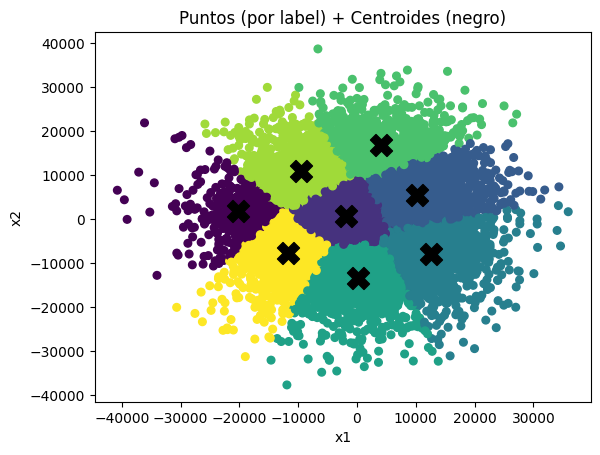

Centros  [[-18968.3515499    1995.44915878]
 [ -1489.10820341    656.45764907]
 [ 10886.71632306   5337.88262853]
 [ 12637.7261283   -7765.90388168]
 [   437.15092404 -13734.41991936]
 [  4154.32392192  16436.21047229]
 [ -9121.20871476  10950.59287258]
 [-11384.12126691  -8050.07824096]]


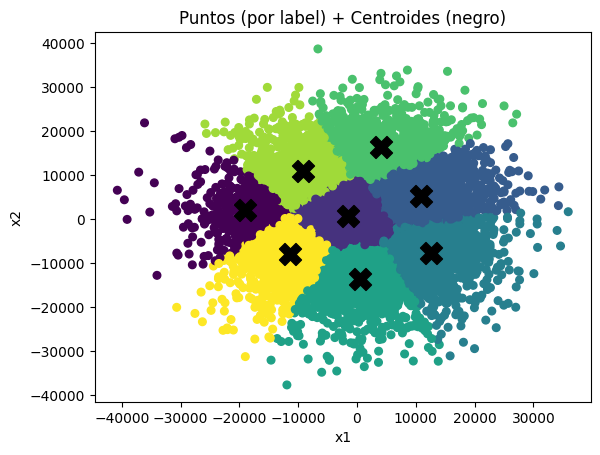

Centros  [[-18020.90360996   2053.35300083]
 [ -1164.30141066    566.61859978]
 [ 11440.03877608   5321.79923675]
 [ 12565.88997916  -7803.30024176]
 [   684.69670852 -14002.58178346]
 [  4274.7636969   16254.66031068]
 [ -8744.76960579  11061.89312537]
 [-11067.51572032  -8377.93215257]]


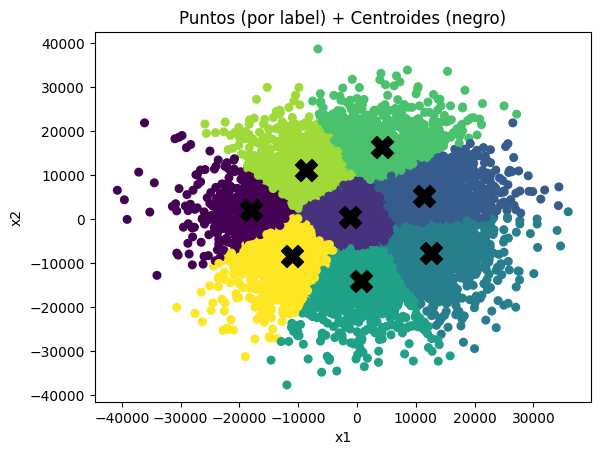

Centros  [[-17199.37617168   1991.80568498]
 [  -883.99683698    480.71352795]
 [ 11889.24561931   5297.64057544]
 [ 12521.06219962  -7854.65642613]
 [   894.27838929 -14291.23696919]
 [  4439.32156569  16078.7922683 ]
 [ -8468.45212867  11222.24007567]
 [-10787.94881925  -8675.63197025]]


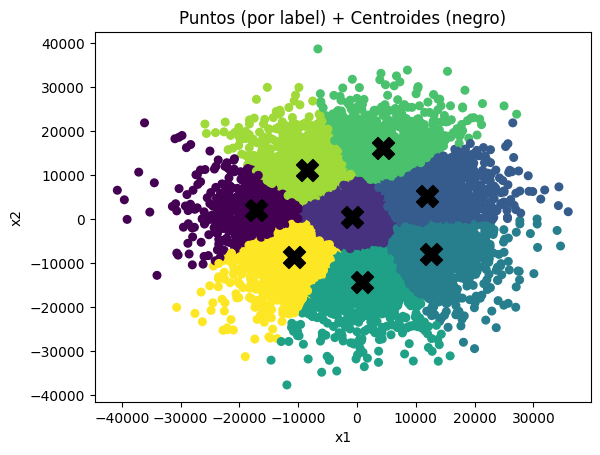

Centros  [[-16570.17789293   1887.9595147 ]
 [  -651.27877017    373.90023195]
 [ 12288.12799665   5267.77561855]
 [ 12449.67972264  -7875.02491893]
 [  1118.04860767 -14558.90398247]
 [  4543.29148442  15988.00374633]
 [ -8202.73456809  11283.53269147]
 [-10574.21684421  -9033.05563696]]


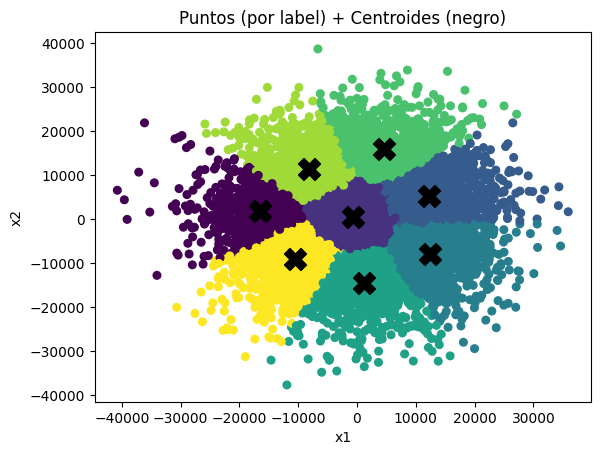

Centros  [[-16163.42057458   1748.21390763]
 [  -489.68532038    295.52650307]
 [ 12583.03150034   5279.37970998]
 [ 12433.13373619  -7926.88837933]
 [  1314.20466867 -14698.65255608]
 [  4581.35622851  15867.51568543]
 [ -8059.91388048  11300.41972235]
 [-10373.47435445  -9346.08219697]]


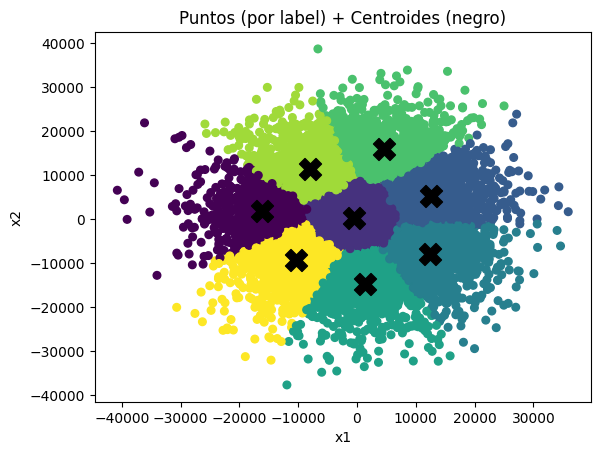

Centros  [[-15796.34121124   1610.16584348]
 [  -340.2544848     205.26848892]
 [ 12794.07735671   5247.24796827]
 [ 12420.88065103  -7959.88073528]
 [  1487.95321496 -14797.85505014]
 [  4621.76521871  15766.08667629]
 [ -7932.5417255   11276.65426655]
 [-10220.25460456  -9584.52712263]]


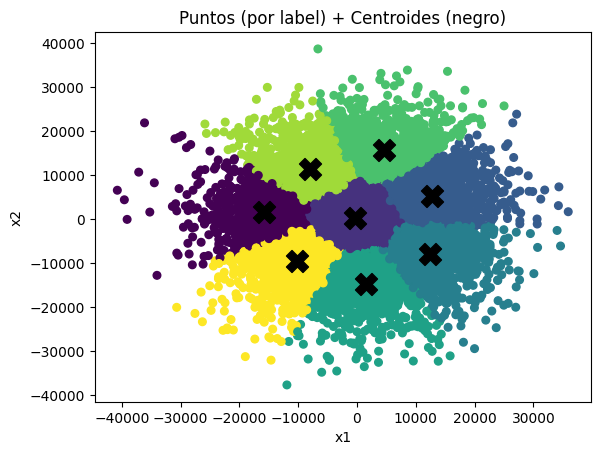

Centros  [[-15556.80552701   1419.36652885]
 [  -189.60766975    127.64044717]
 [ 12959.31624697   5234.9874729 ]
 [ 12469.99220113  -7986.78296126]
 [  1670.94963156 -14891.54269455]
 [  4650.238866    15661.86104981]
 [ -7873.05476697  11222.9872228 ]
 [-10053.01686817  -9809.27469769]]


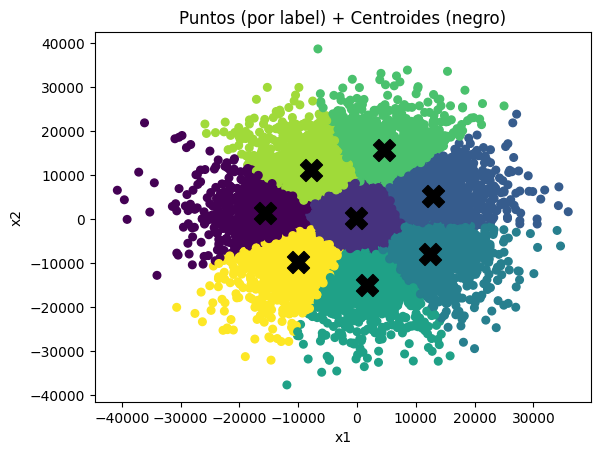

Centros  [[-15367.51306742   1262.00194053]
 [   -71.01956617     60.12327622]
 [ 13088.73512892   5238.29430933]
 [ 12539.16315287  -8014.11871983]
 [  1778.46001835 -14940.8711517 ]
 [  4694.63061337  15588.03657223]
 [ -7818.56847812  11196.28249644]
 [ -9933.50037144  -9992.08901007]]


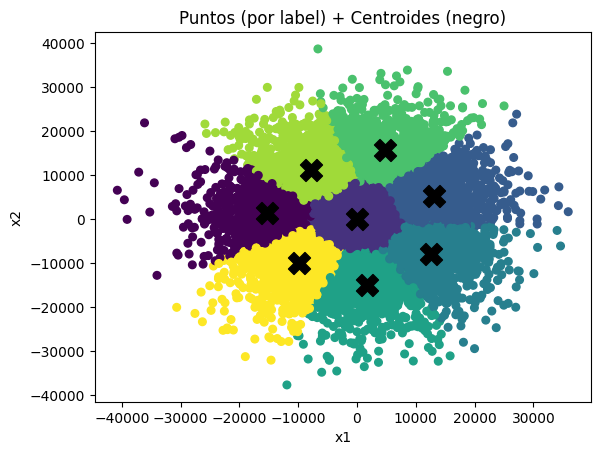

Centros  [[-1.51956356e+04  1.11830055e+03]
 [ 3.69923691e+00  1.11524843e+01]
 [ 1.32191356e+04  5.19995523e+03]
 [ 1.25423298e+04 -8.01004547e+03]
 [ 1.89093201e+03 -1.49710642e+04]
 [ 4.75174465e+03  1.54971668e+04]
 [-7.77443446e+03  1.11791637e+04]
 [-9.84623994e+03 -1.01557450e+04]]


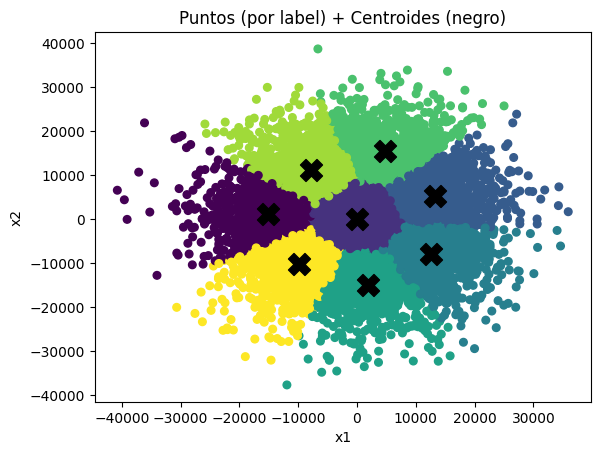

Centros  [[-15068.28396266   1001.40244183]
 [    64.78595939    -30.04896278]
 [ 13326.44801448   5152.47775403]
 [ 12567.35710597  -8000.10019596]
 [  2028.98015325 -15001.72969138]
 [  4820.32257782  15403.95716924]
 [ -7738.01934652  11175.08066169]
 [ -9773.13031295 -10325.47334882]]


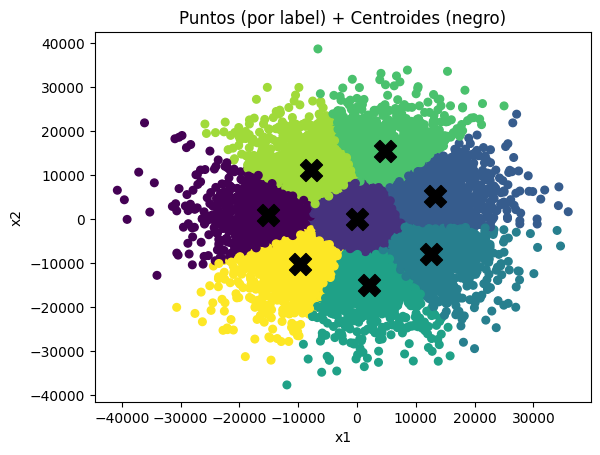

Centros  [[-14975.42650313    915.99260799]
 [   127.03061208    -59.72351428]
 [ 13428.24475849   5123.48716865]
 [ 12589.59207297  -7984.63525587]
 [  2142.45775547 -14998.88820636]
 [  4850.76191587  15339.99675475]
 [ -7693.32984289  11145.20467953]
 [ -9698.75142569 -10451.38175449]]


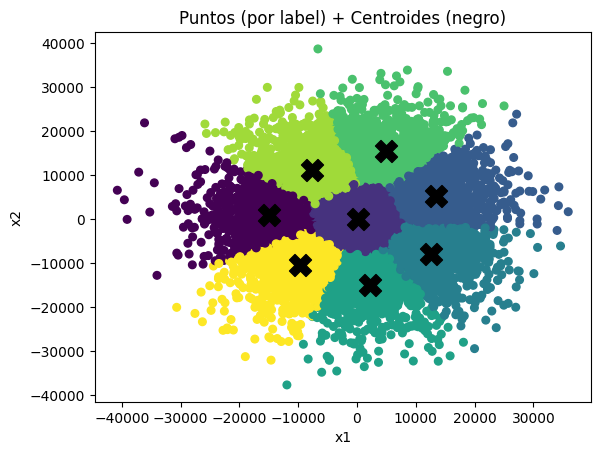

Centros  [[-14886.54774654    859.26325947]
 [   170.19928155    -92.25889917]
 [ 13466.41030527   5108.99561163]
 [ 12657.86153495  -7955.91047068]
 [  2246.11989998 -14962.5298995 ]
 [  4869.37665978  15307.16605773]
 [ -7677.76037438  11106.62250606]
 [ -9684.97387252 -10581.35148081]]


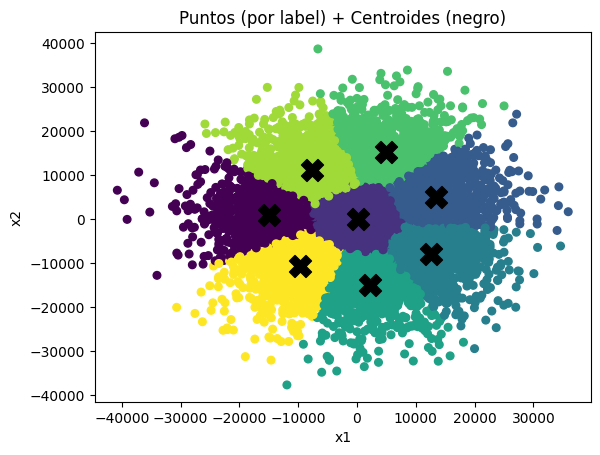

Centros  [[-14810.80720932    809.54540804]
 [   199.43659129   -106.10231455]
 [ 13508.69762227   5121.28286903]
 [ 12685.62725884  -7927.38587378]
 [  2297.73594362 -14961.77018279]
 [  4865.36106232  15300.11357327]
 [ -7687.44335502  11083.81934481]
 [ -9680.31893346 -10661.15891794]]


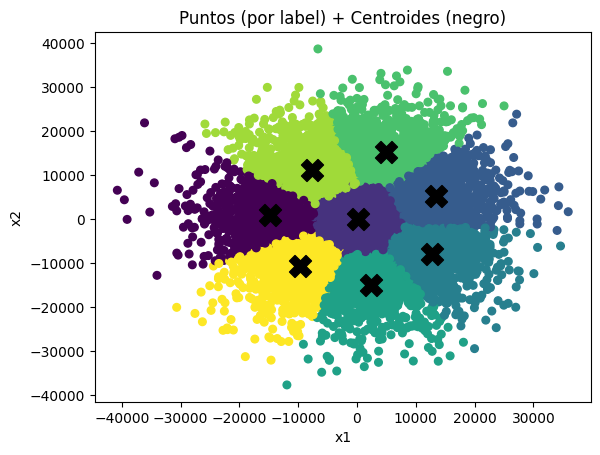

Centros  [[-14760.58594265    748.33124177]
 [   209.46008514   -115.35365641]
 [ 13513.8326319    5126.6658428 ]
 [ 12706.77487273  -7915.60541242]
 [  2320.10135362 -14956.22544574]
 [  4865.36106232  15300.11357327]
 [ -7720.39957371  11082.46768112]
 [ -9675.82118856 -10701.77507684]]


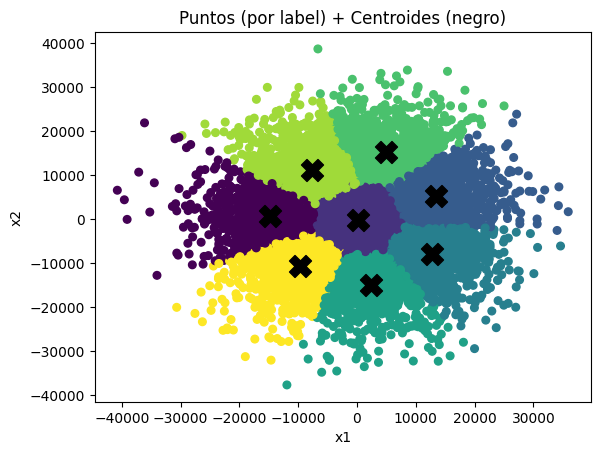

Centros  [[-14724.47876532    707.95222526]
 [   212.7783873    -123.70284487]
 [ 13514.44967299   5138.98107175]
 [ 12738.05861889  -7893.01349833]
 [  2346.57591125 -14931.68538724]
 [  4860.84380175  15293.19301982]
 [ -7748.09545906  11077.35778463]
 [ -9674.8958459  -10732.00341181]]


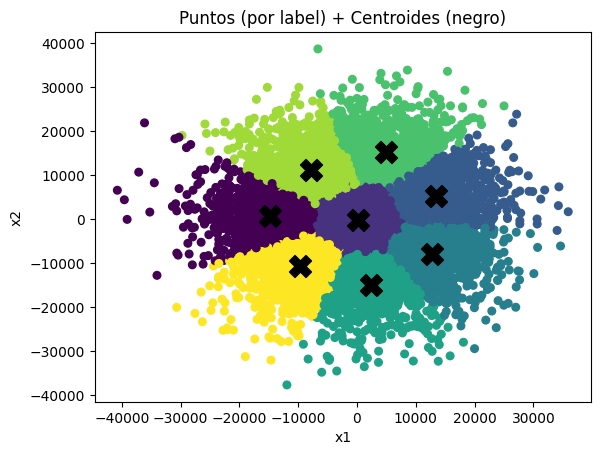

ultimo [5 1 4 ... 3 4 6] 408908293244.7142 [[-14724.47876532    707.95222526]
 [   212.7783873    -123.70284487]
 [ 13514.44967299   5138.98107175]
 [ 12738.05861889  -7893.01349833]
 [  2346.57591125 -14931.68538724]
 [  4860.84380175  15293.19301982]
 [ -7748.09545906  11077.35778463]
 [ -9674.8958459  -10732.00341181]] 20
centros: [[-14895.75521383    695.97794558]
 [    41.50193878   -135.67712456]
 [ 13343.17322447   5127.00679207]
 [ 12566.78217037  -7904.98777801]
 [  2175.29946274 -14943.65966692]
 [  4689.56735324  15281.21874013]
 [ -7919.37190757  11065.38350495]
 [ -9846.17229441 -10743.9776915 ]]
labels: [5 1 4 ... 3 4 6]


In [7]:
import numpy as np
from my_sklearn.cluster._kmeans import KMeans
from sklearn.datasets import make_blobs

x, y = make_blobs(n_samples=10000, centers=5,
                  random_state=500, cluster_std=10100.211)
# X = np.array([[0,0],[0,1],[1,0],[9,9],[9,8],[8,9]])
model = KMeans(n_clusters=8, random_state=0, n_init='auto')
model.fit(x)


print("centros:", model.cluster_centers_)
print("labels:", model.labels_)